## Raw Material Price & Market Sentiment Analyzer

**The Concept:** Forecast price volatility for crucial manufacturing commodities (e.g., semiconductors, rare earth metals, steel) by analyzing global trade news sentiment.

**NLP Component:** Scrape international trade RSS feeds and commodity news headlines. Score the text using statistical lexicons like VADER or SentiWordNet, calculating moving averages of sentiment polarity (positive vs. negative market outlook) over 7-day windows.

**ML Component:** Treat this as a time-series or regression problem. Feed the historical sentiment scores along with past price data into a Ridge Regression or Support Vector Regressor (SVR) to predict commodity price trends for the upcoming week.

**Recruiter Hook:** Directly addresses resource security—a massive pain point for manufacturing-heavy economies and trading houses.

### Setup: Install Libraries

In [6]:

!pip install -q kagglehub[pandas-datasets] nltk

### Load Data and Initial Inspection

In [7]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import nltk
nltk.download('vader_lexicon')

# Set the path to the file you'd like to load.
# Based on the file listing, we found several files. We'll use 'final_gold_data.csv' as an example.
file_path = "final_gold_data.csv" # Changed to a correct filename

print(f"Attempting to load: romanfonel/precious-metals-history-since-2000-with-news/{file_path}")

try:
  df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "romanfonel/precious-metals-history-since-2000-with-news",
    file_path,
    pandas_kwargs={'sep': ';'}
  )
  print("Dataset loaded successfully.")
  print("\nFirst 5 records:")
  display(df.head())
  print("\nDataFrame Info:")
  df.info()
  print("\nDataFrame Description:")
  display(df.describe(include='all'))
except Exception as e:
  print(f"Error loading dataset: {e}")
  print("Please double-check the `file_path` and consider other `pandas_kwargs` like `delimiter`, `quotechar`, or `encoding`.")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
/tmp/ipykernel_1195/2322745111.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Attempting to load: romanfonel/precious-metals-history-since-2000-with-news/final_gold_data.csv


100%|██████████| 4.18M/4.18M [00:00<00:00, 75.9MB/s]


Dataset loaded successfully.

First 5 records:


,timestamp,open,high,low,close,volume,currency,unit,headlines
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6177 entries, 0 to 6176
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  6177 non-null   object 
 1   open       6177 non-null   float64
 2   high       6177 non-null   float64
 3   low        6177 non-null   float64
 4   close      6177 non-null   float64
 5   volume     6177 non-null   int64  
 6   currency   6177 non-null   object 
 7   unit       6177 non-null   object 
 8   headlines  6177 non-null   object 
dtypes: float64(4), int64(1), object(4)
memory usage: 434.4+ KB

DataFrame Description:


,timestamp,open,high,low,close,volume,currency,unit,headlines
count,6177,6177.000000,6177.000000,6177.000000,6177.000000,6177.000000,6177,6177,6177
unique,6177,NaN,NaN,NaN,NaN,NaN,1,1,6177
top,2025-04-14,NaN,NaN,NaN,NaN,NaN,usd,ounce,Star Posts Large Loss in Delayed First-Half Re...
freq,1,NaN,NaN,NaN,NaN,NaN,6177,6177,1
mean,NaN,1181.017241,1186.953392,1174.885090,1181.012304,4298.049377,NaN,NaN,NaN
std,NaN,606.257425,609.741360,602.902334,606.424369,24281.911885,NaN,NaN,NaN
min,NaN,255.000000,256.100000,255.000000,255.100000,0.000000,NaN,NaN,NaN
25%,NaN,636.500000,640.200000,634.000000,635.200000,21.000000,NaN,NaN,NaN
50%,NaN,1238.200000,1243.900000,1231.800000,1238.400000,108.000000,NaN,NaN,NaN
75%,NaN,1641.300000,1652.200000,1630.400000,1640.300000,415.000000,NaN,NaN,NaN


### NLP Component: Sentiment Analysis with VADER

In [8]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Convert 'timestamp' to datetime and set as index
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

# Calculate sentiment scores for each headline
# VADER returns a dictionary with 'neg', 'neu', 'pos', and 'compound' scores.
# The 'compound' score is a normalized, weighted composite score.
df['sentiment_compound'] = df['headlines'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['sentiment_positive'] = df['headlines'].apply(lambda x: sia.polarity_scores(x)['pos'])
df['sentiment_negative'] = df['headlines'].apply(lambda x: sia.polarity_scores(x)['neg'])
df['sentiment_neutral'] = df['headlines'].apply(lambda x: sia.polarity_scores(x)['neu'])

# Calculate 7-day moving average of sentiment polarity (compound score)
df['sentiment_compound_ma7'] = df['sentiment_compound'].rolling(window=7).mean()

print("DataFrame with sentiment scores and 7-day moving average:")
display(df[['headlines', 'sentiment_compound', 'sentiment_compound_ma7']].head(10))
display(df.describe())

DataFrame with sentiment scores and 7-day moving average:


,headlines,sentiment_compound,sentiment_compound_ma7
timestamp,,,
2000-08-30,Recalls Fuel Disclosure Debate / Deutsche Tele...,0.5719,NaN
2000-08-31,Credit Suisse's Wheat Faces Deal / Regulators ...,0.7059,NaN
2000-09-01,Nordstrom's Chief Resigns / Judge Dismisses Ca...,0.7650,NaN
2000-09-05,Market Pace Slows After 10-Year Run / Clickman...,0.8316,NaN
2000-09-06,France Telecom Profit Increases / Locale-Based...,-0.0258,NaN
2000-09-07,"CME Trader Wasn't Frontrunning Orders / Chips,...",0.0000,NaN
2000-09-08,"Euro, Yen Fall as Pound Reaches Seven-Year Low...",-0.6124,0.319457
2000-09-11,Palm Licenses SpeechWorks Software / Solectron...,0.6705,0.333543
2000-09-12,Duisenberg's Statement / Chase Is in Talks To ...,-0.4939,0.162143


,open,high,low,close,volume,sentiment_compound,sentiment_positive,sentiment_negative,sentiment_neutral,sentiment_compound_ma7
count,6177.000000,6177.000000,6177.000000,6177.000000,6177.000000,6177.000000,6177.000000,6177.000000,6177.000000,6171.000000
mean,1181.017241,1186.953392,1174.885090,1181.012304,4298.049377,-0.196315,0.093508,0.117042,0.789445,-0.196549
std,606.257425,609.741360,602.902334,606.424369,24281.911885,0.632849,0.061675,0.068669,0.080764,0.311764
min,255.000000,256.100000,255.000000,255.100000,0.000000,-0.991500,0.000000,0.000000,0.297000,-0.960214
25%,636.500000,640.200000,634.000000,635.200000,21.000000,-0.802000,0.056000,0.075000,0.744000,-0.423479
50%,1238.200000,1243.900000,1231.800000,1238.400000,108.000000,-0.318200,0.088000,0.114000,0.791000,-0.197514
75%,1641.300000,1652.200000,1630.400000,1640.300000,415.000000,0.393900,0.124000,0.154000,0.836000,0.024679
max,3215.500000,3235.000000,3194.500000,3222.200000,386334.000000,0.985300,0.565000,0.577000,1.000000,0.725929


### ML Component: Feature Engineering and Target Variable Definition

### ML Component: Model Training and Evaluation

#### Data Splitting for Time Series

For time series data, it's crucial to split the data chronologically to prevent data leakage. We'll use the first 80% of the data for training and the remaining 20% for testing.

In [11]:
from sklearn.model_selection import train_test_split

# For time series, a simple train-test split is not appropriate as it shuffles data.
# We need to split chronologically.
split_point = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (4925, 12)
Testing features shape: (1232, 12)
Training target shape: (4925,)
Testing target shape: (1232,)


#### Ridge Regression Model

Ridge Regression - Mean Squared Error: 2489.3113
Ridge Regression - R-squared: 0.9778


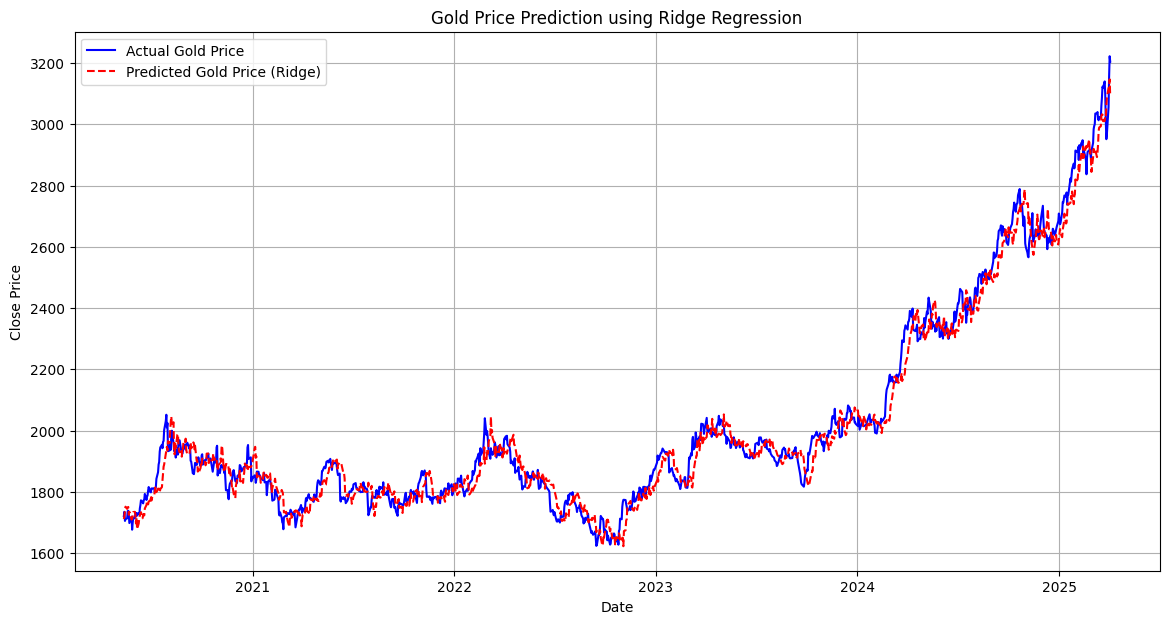

In [12]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Initialize and train the Ridge Regression model
ridge_model = Ridge(alpha=1.0) # Alpha is the regularization strength
ridge_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate the model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression - Mean Squared Error: {mse_ridge:.4f}")
print(f"Ridge Regression - R-squared: {r2_ridge:.4f}")

# Plot actual vs. predicted values for Ridge Regression
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Gold Price', color='blue')
plt.plot(y_test.index, y_pred_ridge, label='Predicted Gold Price (Ridge)', color='red', linestyle='--')
plt.title('Gold Price Prediction using Ridge Regression')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

#### Support Vector Regressor (SVR) Model

Training SVR model... This might take a while.
SVR training complete.

SVR - Mean Squared Error: 2596.6688
SVR - R-squared: 0.9768


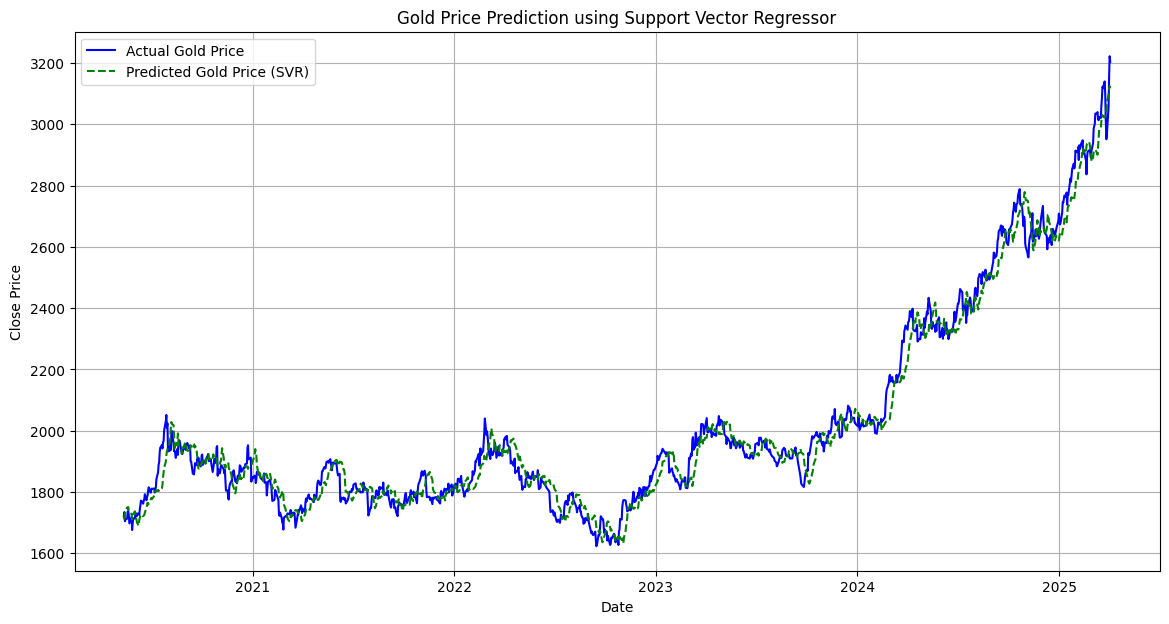

In [13]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVR is sensitive to feature scaling, so we'll scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SVR model
# Using a linear kernel for simplicity, can experiment with rbf, poly etc.
svr_model = SVR(kernel='linear', C=1.0, epsilon=0.1)
# C is the regularization parameter, epsilon defines the epsilon-tube within which no penalty is associated in the training loss function

print("Training SVR model... This might take a while.")
svr_model.fit(X_train_scaled, y_train)
print("SVR training complete.")

# Make predictions on the scaled test set
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluate the model
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"\nSVR - Mean Squared Error: {mse_svr:.4f}")
print(f"SVR - R-squared: {r2_svr:.4f}")

# Plot actual vs. predicted values for SVR
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Gold Price', color='blue')
plt.plot(y_test.index, y_pred_svr, label='Predicted Gold Price (SVR)', color='green', linestyle='--')
plt.title('Gold Price Prediction using Support Vector Regressor')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

#### Model Comparison

In [14]:
# This cell performs evaluation and comparison of Ridge Regression and SVR models.
# It assumes that 'mse_ridge', 'r2_ridge', 'mse_svr', and 'r2_svr'
# have been calculated and are available from previous cells (e.g., model training and evaluation cells).

print("\n--- Model Comparison ---")
print(f"Ridge Regression - Mean Squared Error: {mse_ridge:.4f}")
print(f"Ridge Regression - R-squared: {r2_ridge:.4f}")
print(f"SVR - Mean Squared Error: {mse_svr:.4f}")
print(f"SVR - R-squared: {r2_svr:.4f}")

if r2_ridge > r2_svr:
    print(f"\nRidge Regression has a higher R-squared ({r2_ridge:.4f}) than SVR ({r2_svr:.4f}), indicating a slightly better fit to the data.")
else:
    print(f"\nSVR has a higher R-squared ({r2_svr:.4f}) than Ridge Regression ({r2_ridge:.4f}), indicating a slightly better fit to the data.")

if mse_ridge < mse_svr:
    print(f"Ridge Regression has a lower MSE ({mse_ridge:.4f}) than SVR ({mse_svr:.4f}), suggesting better predictive accuracy.")
else:
    print(f"SVR has a lower MSE ({mse_svr:.4f}) than Ridge Regression ({mse_ridge:.4f}), suggesting better predictive accuracy.")



--- Model Comparison ---
Ridge Regression - Mean Squared Error: 2489.3113
Ridge Regression - R-squared: 0.9778
SVR - Mean Squared Error: 2596.6688
SVR - R-squared: 0.9768

Ridge Regression has a higher R-squared (0.9778) than SVR (0.9768), indicating a slightly better fit to the data.
Ridge Regression has a lower MSE (2489.3113) than SVR (2596.6688), suggesting better predictive accuracy.


In [ ]:
import numpy as np

# Drop rows with NaN values resulting from moving average calculation
df_ml = df.dropna().copy()

# Define the target variable: 'close' price for the next week (7 days)
# We'll shift the 'close' price upwards by 7 days to get the target for the current row
df_ml['target_close_next_week'] = df_ml['close'].shift(-7)

# Create lagged features for 'close' price and 'sentiment_compound_ma7'
# Let's consider lags for 1, 3, and 7 days for both price and sentiment
lags = [1, 3, 7]

for lag in lags:
    df_ml[f'close_lag_{lag}'] = df_ml['close'].shift(lag)
    df_ml[f'sentiment_ma7_lag_{lag}'] = df_ml['sentiment_compound_ma7'].shift(lag)

# Drop any remaining NaN values that resulted from shifting (especially the target and lagged features)
df_ml.dropna(inplace=True)

# Select features and target
features = [
    'open', 'high', 'low', 'close', 'volume',
    'sentiment_compound_ma7',
    *[f'close_lag_{l}' for l in lags],
    *[f'sentiment_ma7_lag_{l}' for l in lags]
]
target = 'target_close_next_week'

X = df_ml[features]
y = df_ml[target]

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("\nFeatures and target head:")
display(df_ml[features + [target]].head())


### List Dataset Files to Identify Correct Path

In [ ]:
import kagglehub
import os

print("Downloading dataset 'romanfonel/precious-metals-history-since-2000-with-news'...")
# Download the dataset to get access to its files locally
download_path = kagglehub.dataset_download('romanfonel/precious-metals-history-since-2000-with-news')

print(f"Dataset downloaded to: {download_path}")
print("\nListing files in the downloaded directory:")
for root, dirs, files in os.walk(download_path):
    for name in files:
        print(os.path.join(root, name))
